# Internet Coverage Analysis

## 1. Data Loading

In [1]:
import pandas as pd

master_df = pd.read_csv("Internet.csv")
master_df.head()

,Neighborhood,Fiber_Available,FWA_Available,Mobile_Available
0,Al Amal Dist.,0,1,1
1,Al Namudhajiyah Dist.,0,1,1
2,Al Jarradiyah Dist.,1,1,1
3,Al Sinaiyah Dist.,0,1,1
4,Manfuha Al Jadidah Dist.,0,1,1


In [13]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Neighborhood      189 non-null    object
 1   Fiber_Available   189 non-null    int64 
 2   FWA_Available     189 non-null    int64 
 3   Mobile_Available  189 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.0+ KB


In [15]:
master_df.isnull().sum()

,0
Neighborhood,0
Fiber_Available,0
FWA_Available,0
Mobile_Available,0


In [18]:
master_df.duplicated().sum()

np.int64(0)

## 2. Load JSON Data

In [4]:
import zipfile

with zipfile.ZipFile("neighborhoods_internet_info.zip", 'r') as zip_ref:
    zip_ref.extractall("neighborhoods")

In [5]:
import os
import json

all_data = []

for file in os.listdir("neighborhoods"):
    if file.endswith(".json"):
        with open(os.path.join("neighborhoods", file), encoding="utf-8") as f:
            data = json.load(f)
            for row in data["data"]:
                row["Neighborhood"] = data["neighborhood"]
                all_data.append(row)

eda_df = pd.DataFrame(all_data)
eda_df.head()

,Type,Provider,Metric,Value,Neighborhood
0,Fiber,not_available,availability,not_available,Ghobairah Dist.
1,Fiber,not_available,download_mbps,not_available,Ghobairah Dist.
2,Fiber,not_available,upload_mbps,not_available,Ghobairah Dist.
3,FWA,STC,availability,1,Ghobairah Dist.
4,FWA,STC,download_mbps,300,Ghobairah Dist.


### 3. Service Providers

The dataset includes 5 main internet service providers operating across the neighborhoods.

In [19]:
providers = eda_df["Provider"].dropna().unique()

for p in sorted(providers):
    if p != "not_available":
        print(f"- {p}")

- GO
- Mobily
- STC
- Salam
- Zain


## 4. Internet Availability
Mobile is usually the most available.

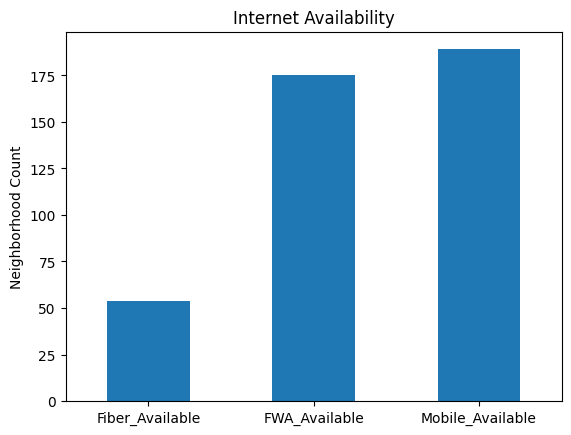

In [6]:
import matplotlib.pyplot as plt

availability_counts = master_df[[
    "Fiber_Available",
    "FWA_Available",
    "Mobile_Available"
]].sum()

availability_counts.plot(kind="bar")
plt.title("Internet Availability")
plt.ylabel("Neighborhood Count")
plt.xticks(rotation=0)
plt.show()

## 5. FWA Download Speed
Speeds are often similar across providers.

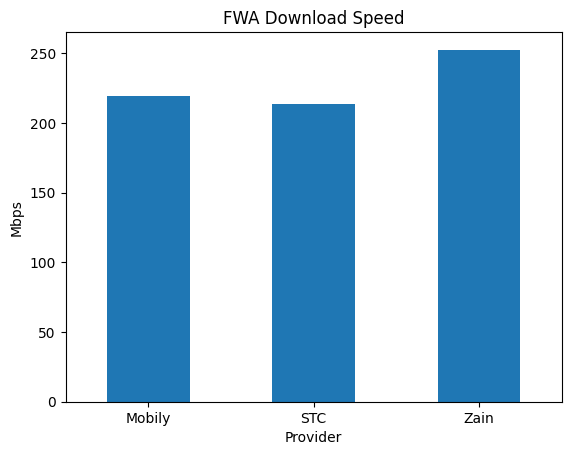

In [7]:
fwa_download = eda_df[
    (eda_df["Type"] == "FWA") &
    (eda_df["Metric"] == "download_mbps")
]

fwa_download = fwa_download[fwa_download["Value"] != "not_available"]
fwa_download["Value"] = fwa_download["Value"].astype(int)

avg_download = fwa_download.groupby("Provider")["Value"].mean()

avg_download.plot(kind="bar")
plt.title("FWA Download Speed")
plt.ylabel("Mbps")
plt.xticks(rotation=0)
plt.show()

## 6. 5G Quality
Most values are between good and excellent.

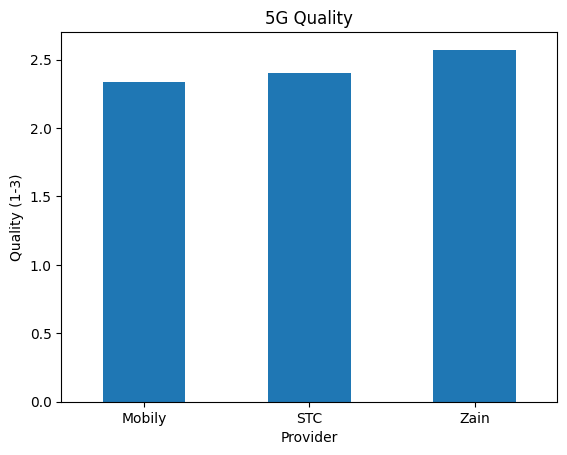

In [8]:
mobile_5g = eda_df[
    (eda_df["Type"] == "Mobile") &
    (eda_df["Metric"] == "5G")
]

mobile_5g = mobile_5g[mobile_5g["Value"] != "not_available"]
mobile_5g["Value"] = mobile_5g["Value"].astype(int)

avg_5g = mobile_5g.groupby("Provider")["Value"].mean()

avg_5g.plot(kind="bar")
plt.title("5G Quality")
plt.ylabel("Quality (1-3)")
plt.xticks(rotation=0)
plt.show()

## 7. Best Provider per Neighborhood

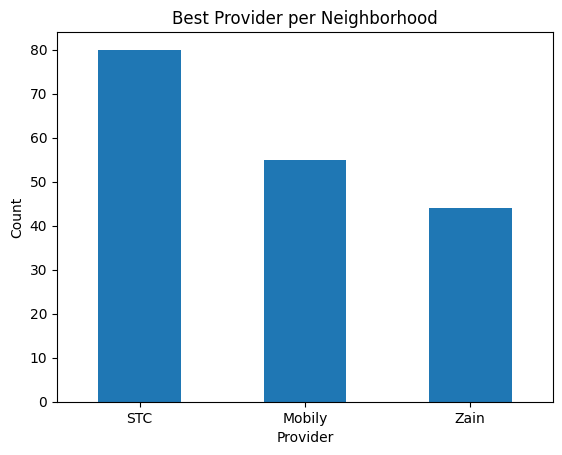

In [9]:
best_5g = mobile_5g.loc[
    mobile_5g.groupby("Neighborhood")["Value"].idxmax()
]

best_counts = best_5g["Provider"].value_counts()

best_counts.plot(kind="bar")
plt.title("Best Provider per Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 7. Neighborhood Scoring

In [10]:
mobile_score = mobile_5g.groupby("Neighborhood")["Value"].mean()
fwa_score = fwa_download.groupby("Neighborhood")["Value"].mean()

score_df = pd.concat([mobile_score, fwa_score], axis=1)
score_df.columns = ["Mobile_5G_Quality", "FWA_Download"]

score_df = score_df.fillna(0)

score_df["Total_Score"] = (
    score_df["Mobile_5G_Quality"] * 10 +
    score_df["FWA_Download"]
)

score_df.sort_values("Total_Score", ascending=False).head()

,Mobile_5G_Quality,FWA_Download,Total_Score
Neighborhood,,,
Al Badiah Dist.,3.0,300.0,330.0
Al Muhammadiyah Dist.,3.0,300.0,330.0
Al Khalidiyah Dist.,3.0,300.0,330.0
Al Jarradiyah Dist.,3.0,300.0,330.0
Al Mansurah Dist.,3.0,300.0,330.0


####1- Top Areas

In [24]:
max_score = score_df["Total_Score"].max()

top_neighborhoods = score_df[score_df["Total_Score"] == max_score]

len(top_neighborhoods)

24

In [25]:
for name in top_neighborhoods.index:
  print(name)

Al Badiah Dist.
Al Jarradiyah Dist.
Al Khalidiyah Dist.
Al Mansurah Dist.
Al Muhammadiyah Dist.
Al Murabba Dist.
Al Nadwah Dist.
Al Olaya Dist.
Al Rabiyah Dist.
Al Raed Dist.
Al Sinaiyah Dist.
Al Ula Dist.
Al Uraija Dist.
Al Wadi Dist.
Al Yamamah Dist.
Al Zahra Dist.
Assafarat Dist.
East Naseem Dist.
Ghirnatah Dist.
Ghobairah Dist.
Manfuha Al Jadidah Dist.
Manfuhah Dist.
Umm Saleem Dist.
West Oraija Dist.


####2-  Weak Areas

In [26]:
min_score = score_df["Total_Score"].min()

bottom_neighborhoods = score_df[score_df["Total_Score"] == min_score]

len(bottom_neighborhoods)

13

In [27]:
for name in bottom_neighborhoods.index:
  print(name)

Al Ammajiyah Dist.
Al Danah Dist.
Al Khuzama Dist.
Al Marjan Dist.
Al Risalah Dist.
Al Sholah Dist.
Al Sidrah Dist.
Al Tadamun Dist.
Al Wasam Dist.
Al Zaher Dist.
Al Zahour Dist.
Banban Dist.
Dahiyat Namar Dist.
